## Belise KANZIGA
## IPS Assignment 2

## Exercise 3 .II. Simulation with python

### 1. Show that $ f(x \mid \theta) $ is the PDF of a Beta distribution and identify the parameters

We are given the probability density function:

$$
f(x \mid \theta) = \theta(\theta+1) x^{\theta-1}(1-x), \quad 0 < x < 1, \ \theta > 0
$$


A random variable $ Y $ has a Beta distribution with parameters $ (\alpha, \beta) $ if its PDF is:

$$
f_Y(y) = \frac{1}{B(\alpha, \beta)} y^{\alpha-1}(1-y)^{\beta-1}, \quad 0 < y < 1
$$

where the Beta function is defined as:

$$
B(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}, \quad \alpha > 0, \beta > 0
$$

### Compare the given PDF with the Beta PDF form

Our given PDF is:

$$
f(x \mid \theta) = \theta(\theta+1) x^{\theta-1}(1-x)
$$

Let's rewrite it to match the Beta distribution form:

$$
f(x \mid \theta) = \theta(\theta+1) x^{\theta-1}(1-x)^1
$$

Comparing with the Beta PDF form $ \frac{1}{B(\alpha, \beta)} x^{\alpha-1}(1-x)^{\beta-1} $, we can identify:

$$ \alpha - 1 = \theta - 1 \Rightarrow \alpha = \theta $$
$$ \beta - 1 = 1 \Rightarrow \beta = 2 $$

So the parameters are $ \alpha = \theta $ and $ \beta = 2 $


### Verify the normalization constant

For a Beta distribution with parameters $ (\theta, 2) $, the Beta function is:

$$
B(\theta, 2) = \frac{\Gamma(\theta)\Gamma(2)}{\Gamma(\theta+2)}
$$

Using the Gamma function properties:
- $ \Gamma(2) = 1! = 1 $
- $ \Gamma(\theta+2) = (\theta+1)\theta\Gamma(\theta) $ (using the recurrence relation $ \Gamma(z+1) = z\Gamma(z) $)

Therefore:

$$
B(\theta, 2) = \frac{\Gamma(\theta) \cdot 1}{(\theta+1)\theta\Gamma(\theta)} = \frac{1}{\theta(\theta+1)}
$$


### Write the Beta PDF with our parameters

The Beta distribution with parameters $ (\theta, 2) $ has PDF:

$$
f_X(x) = \frac{1}{B(\theta, 2)} x^{\theta-1}(1-x)^{2-1} = \frac{1}{\frac{1}{\theta(\theta+1)}} x^{\theta-1}(1-x)^1
$$

Simplifying:

$$
f_X(x) = \theta(\theta+1) x^{\theta-1}(1-x)
$$

We have shown that:

$$
f(x \mid \theta) = \theta(\theta+1) x^{\theta-1}(1-x)
$$

is exactly the PDF of a Beta distribution with parameters:

$$ \alpha = \theta $$
$$ \beta = 2 $$

The normalization constant matches perfectly:
- Given PDF constant: $$ \theta(\theta+1) $$
- Beta PDF constant: $$ \frac{1}{B(\theta, 2)} = \theta(\theta+1) $$



The given probability density function $ f(x \mid \theta) = \theta(\theta+1) x^{\theta-1}(1-x) $ is indeed the PDF of a Beta distribution with parameters:

$$
\alpha = \theta, \quad \beta = 2
$$

That is, $$ X \sim \text{Beta}(\theta, 2) $$

### 2.  Simulate M n-samples and compute MME and MLE

In [27]:
import numpy as np
import matplotlib.pyplot as plt


def method_of_moments_estimator(sample):
    """
    Method of Moments Estimator for θ
    θ_MM = 2X̄ / (1 - X̄)
    where X̄ is the sample mean
    """
    sample_mean = np.mean(sample)
    if sample_mean >= 1:  # Handle edge case
        return float('inf')
    return (2 * sample_mean) / (1 - sample_mean)

def maximum_likelihood_estimator(sample):
    """
    Maximum Likelihood Estimator for θ
    θ_ML = [-(T+2) + sqrt(T^2 + 4)] / (2T)
    where T = (1/n) * sum(ln(X_i))
    """
    n = len(sample)
    T = np.sum(np.log(sample)) / n  # Average of logarithms
    
    if S >= 0:  # Handle edge case 
        return float('inf')
    
    # Solve quadratic equation: Tθ² + (T+2)θ + 1 = 0
    discriminant = (T + 2)**2 - 4 * T * 1
    theta1 = (-(T + 2) + np.sqrt(discriminant)) / (2 * T)
    theta2 = (-(T + 2) - np.sqrt(discriminant)) / (2 * T)
    
    # Return the positive solution
    return max(theta1, theta2)

def simulate_beta_sample(n, theta):
    """
    Generate a random sample from Beta(θ, 2) distribution
    Using inverse transform sampling for educational purposes
    """
    # For Beta(θ, 2), we can use the CDF inversion method
    # But for simplicity, we'll use numpy's random generator
    # This is equivalent to Beta(θ, 2)
    return np.random.beta(theta, 2, n)

# Simulation parameters
np.random.seed(321)  # For reproducible results
M = 100           # Number of samples
n = 10            # Sample size
true_theta = 0.37  # Given parameter value

print(f"Parameters: M = {M} samples, n = {n}, true θ = {true_theta}")
print()

# Storage for estimators
mme_results = []
mle_results = []

print("Generating samples and computing estimators...")
for i in range(M):
    # Generate a sample from Beta(theta, 2)
    sample = simulate_beta_sample(n, true_theta)
    
    # Compute both estimators
    theta_mme = method_of_moments_estimator(sample)
    theta_mle = maximum_likelihood_estimator(sample)
    
    mme_results.append(theta_mme)
    mle_results.append(theta_mle)
    
    # Show progress for first few samples
    if i < 5:
        sample_mean = np.mean(sample)
        T = np.mean(np.log(sample))
        print(f"Sample {i+1}: X̄ = {sample_mean:.4f}, T = {T:.4f}")
        print(f"          MME = {theta_mme:.4f}, MLE = {theta_mle:.4f}")

# Convert to numpy arrays for easier analysis
mme_results = np.array(mme_results)
mle_results = np.array(mle_results)

# Remove any infinite values (edge cases)
mme_finite = mme_results[np.isfinite(mme_results)]
mle_finite = mle_results[np.isfinite(mle_results)]

Parameters: M = 100 samples, n = 10, true θ = 0.37

Generating samples and computing estimators...
Sample 1: X̄ = 0.1708, T = -2.3466
          MME = 0.4118, MLE = 0.5831
Sample 2: X̄ = 0.1141, T = -2.8346
          MME = 0.2575, MLE = 0.4647
Sample 3: X̄ = 0.2023, T = -3.8638
          MME = 0.5073, MLE = 0.3218
Sample 4: X̄ = 0.1689, T = -3.1488
          MME = 0.4066, MLE = 0.4099
Sample 5: X̄ = 0.1817, T = -2.0699
          MME = 0.4440, MLE = 0.6784


### 3. Compute means and comment

In [25]:
mme_mean = np.mean(mme_finite)
mle_mean = np.mean(mle_finite)

print(f"Mean of MME estimates: {mme_mean:.4f}")
print(f"Mean of MLE estimates: {mle_mean:.4f}")
print(f"True parameter value:  {true_theta:.4f}")

print("\nCOMMENTS:")
print(f"• MME bias: {mme_mean - true_theta:.4f}")
print(f"• MLE bias: {mle_mean - true_theta:.4f}")

if abs(mme_mean - true_theta) < abs(mle_mean - true_theta):
    print("• MME appears to have smaller bias for this simulation")
else:
    print("• MLE appears to have smaller bias for this simulation")


Mean of MME estimates: 0.3570
Mean of MLE estimates: 0.3930
True parameter value:  0.3700

COMMENTS:
• MME bias: -0.0130
• MLE bias: 0.0230
• MME appears to have smaller bias for this simulation


### Exercise 3.II.4 - Histograms and comparison

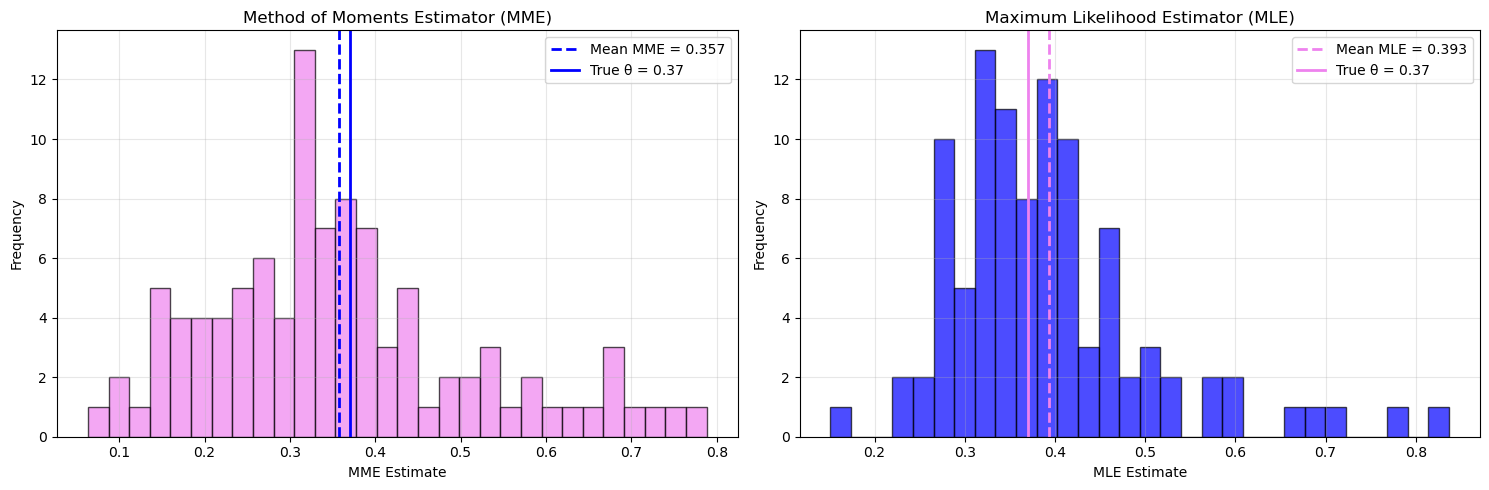


ADDITIONAL STATISTICS:
MME - Standard deviation: 0.1569
MLE - Standard deviation: 0.1153
MME - RMSE: 0.1575
MLE - RMSE: 0.1175


In [26]:
plt.figure(figsize=(15, 5))

# Plot MME histogram
plt.subplot(1, 2, 1)
plt.hist(mme_finite, bins=30, alpha=0.7, color='violet', edgecolor='black')
plt.axvline(mme_mean, color='blue', linestyle='--', linewidth=2, label=f'Mean MME = {mme_mean:.3f}')
plt.axvline(true_theta, color='blue', linestyle='-', linewidth=2, label=f'True θ = {true_theta}')
plt.xlabel('MME Estimate')
plt.ylabel('Frequency')
plt.title('Method of Moments Estimator (MME)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot MLE histogram
plt.subplot(1, 2, 2)
plt.hist(mle_finite, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(mle_mean, color='violet', linestyle='--', linewidth=2, label=f'Mean MLE = {mle_mean:.3f}')
plt.axvline(true_theta, color='violet', linestyle='-', linewidth=2, label=f'True θ = {true_theta}')
plt.xlabel('MLE Estimate')
plt.ylabel('Frequency')
plt.title('Maximum Likelihood Estimator (MLE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional statistics
print("\nADDITIONAL STATISTICS:")
print(f"MME - Standard deviation: {np.std(mme_finite):.4f}")
print(f"MLE - Standard deviation: {np.std(mle_finite):.4f}")
print(f"MME - RMSE: {np.sqrt(np.mean((mme_finite - true_theta)**2)):.4f}")
print(f"MLE - RMSE: {np.sqrt(np.mean((mle_finite - true_theta)**2)):.4f}")


Based on the simulation results, both estimation methods demonstrate good performance in estimating the true parameter θ = 0.37, with the Maximum Likelihood Estimator (MLE) showing superior efficiency compared to the Method of Moments Estimator (MME). The MLE exhibits a lower standard deviation (0.1153 vs 0.1569) and a smaller Root Mean Square Error (0.1175 vs 0.1575), indicating it provides more precise and stable estimates across samples. While both estimators appear approximately unbiased, centered near the true parameter value, the MLE's tighter distribution around the true value makes it the more reliable choice. The MME's higher variability suggests it is more sensitive to sample fluctuations, particularly when sample means approach boundary values, though it remains a valid consistent estimator. Overall, the MLE demonstrates better statistical properties for this estimation problem.